# Benchmark Dataframe Explorer
Interactive exploration of `outputs/benchmark_dataframe.parquet` — 645 k variants × 227 columns.

In [38]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Global style ───────────────────────────────────────────────────────────
sns.set_theme(style='ticks', font_scale=1.25)
mpl.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.framealpha': 0.85,
    'figure.constrained_layout.use': True,
})

# ── Reusable helpers ───────────────────────────────────────────────────────
LABEL_PALETTE = {
    'loss_of_function': '#d62728',
    'intermediate':     '#ff7f0e',
    'functional':       '#2ca02c',
}

def comma_fmt(x, _=None):
    return f'{int(x):,}'

def annotate_bars(ax, fmt='{:,.0f}', fontsize=9, pad=3, color='#333333'):
    """Add value labels to the end of every bar in ax."""
    for p in ax.patches:
        w, h = p.get_width(), p.get_height()
        if ax.get_xaxis().get_scale() == 'linear' and w == 0:
            continue
        if h == 0 and w == 0:
            continue
        is_horiz = (h < w) and (h <= 1.0)
        if is_horiz:
            ax.text(w + pad, p.get_y() + h / 2,
                    fmt.format(w), va='center', ha='left', fontsize=fontsize, color=color)
        else:
            ax.text(p.get_x() + w / 2, h + pad,
                    fmt.format(h), va='bottom', ha='center', fontsize=fontsize, color=color)

# ── Load data ──────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

PARQUET = Path('outputs/benchmark_dataframe.parquet')
df = pd.read_parquet(PARQUET)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded: 645,343 rows × 227 columns


---
## 1. Schema & Null Coverage

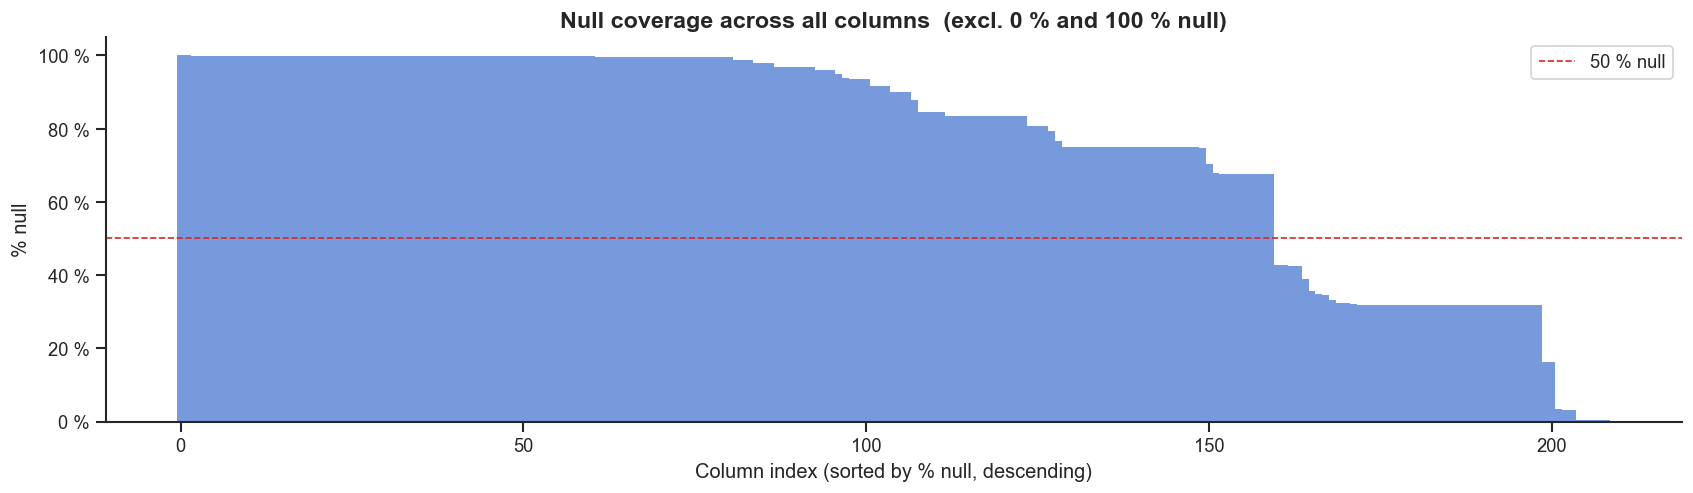

Key score null %:
Pillar          33.2051
VampSeq         96.8011
LabelSeq        83.4468
FISSeq          99.7050
AlphaMissense   76.5660
REVEL           74.8021
SpliceAI        70.2918


In [39]:
COORD_COLS   = ['variant_id','gene','chrom','hg38_pos','ref_allele','alt_allele',
                'hgvs_c','hgvs_p','consequence','simplified_consequence','variant_type_harmonized']
SCORE_COLS   = ['functional_score_pillar','functional_score_vampseq','functional_score_labelseq',
                'functional_score_fisseq','alphamissense_score','revel_score','spliceai_max_ds']
SCORE_LABELS = ['Pillar','VampSeq','LabelSeq','FISSeq','AlphaMissense','REVEL','SpliceAI']
LABEL_COLS   = ['functional_class_pillar','consensus_functional_label',
                'consensus_functional_score','conflict_flag','is_duplicate_flag','low_coverage_flag']

null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_filtered = null_pct[(null_pct > 0) & (null_pct < 100)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(null_filtered)), null_filtered.values, width=1.0,
       color='#4878cf', alpha=0.75, linewidth=0)
ax.axhline(50, color='#d62728', linewidth=1, linestyle='--', label='50 % null')
ax.set_xlabel('Column index (sorted by % null, descending)')
ax.set_ylabel('% null')
ax.set_title('Null coverage across all columns  (excl. 0 % and 100 % null)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f} %'))
plt.show()

print('Key score null %:')
print(null_pct[SCORE_COLS].rename(dict(zip(SCORE_COLS, SCORE_LABELS))).to_string())

In [40]:
print('Column dtype breakdown:')
print(df.dtypes.value_counts().to_string())
print()
print('Sample rows (core columns):')
df[COORD_COLS].dropna(subset=['gene']).head(8)

Column dtype breakdown:
object     127
float64     83
Int64       11
bool         6

Sample rows (core columns):


,variant_id,gene,chrom,hg38_pos,ref_allele,alt_allele,hgvs_c,hgvs_p,consequence,simplified_consequence,variant_type_harmonized
0,None,ARAF,None,<NA>,None,None,None,None,None,None,None
1,None,ARAF,None,<NA>,None,None,None,None,None,None,None
2,None,ARAF,None,<NA>,None,None,None,None,None,None,None
3,None,ARAF,None,<NA>,None,None,None,None,None,None,None
4,None,ARAF,None,<NA>,None,None,None,None,None,None,None
5,None,ARAF,None,<NA>,None,None,None,None,None,None,None
6,None,ARAF,None,<NA>,None,None,None,None,None,None,None
7,None,ARAF,None,<NA>,None,None,None,None,None,None,None


---
## 2. Variant Landscape

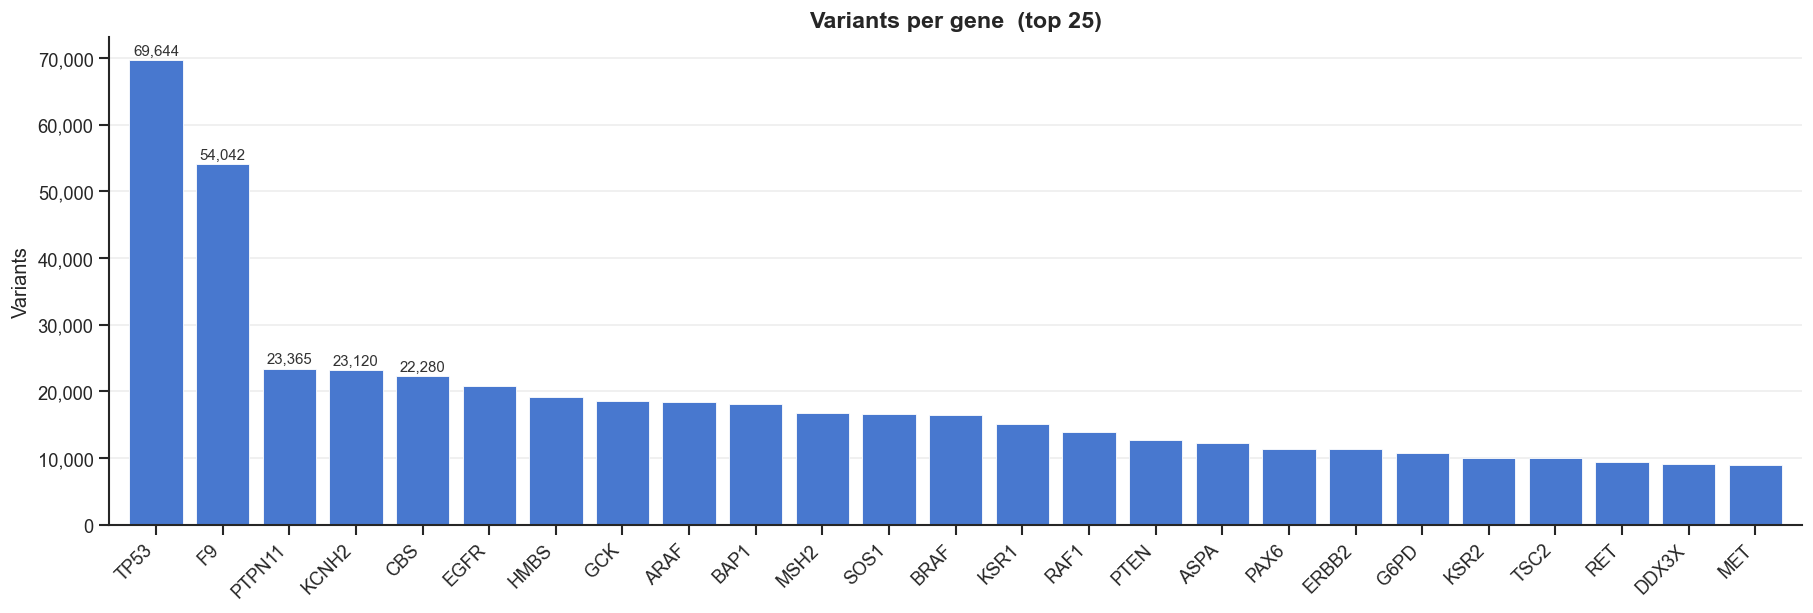

Total unique genes: 58


In [41]:
gene_counts = df['gene'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(range(len(gene_counts)), gene_counts.values, color='#4878cf', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(gene_counts)))
ax.set_xticklabels(gene_counts.index, rotation=45, ha='right', fontsize=11)
ax.set_title('Variants per gene  (top 25)')
ax.set_ylabel('Variants')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(comma_fmt))
ax.set_xlim(-0.7, len(gene_counts) - 0.3)
ax.grid(axis='y', alpha=0.35)

# value labels on tallest bars only
threshold = gene_counts.values.max() * 0.3
for bar, val in zip(bars, gene_counts.values):
    if val >= threshold:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 400,
                f'{val:,}', ha='center', va='bottom', fontsize=9, color='#333')

plt.show()
print(f'Total unique genes: {df["gene"].nunique()}')

C:\Users\Hat\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


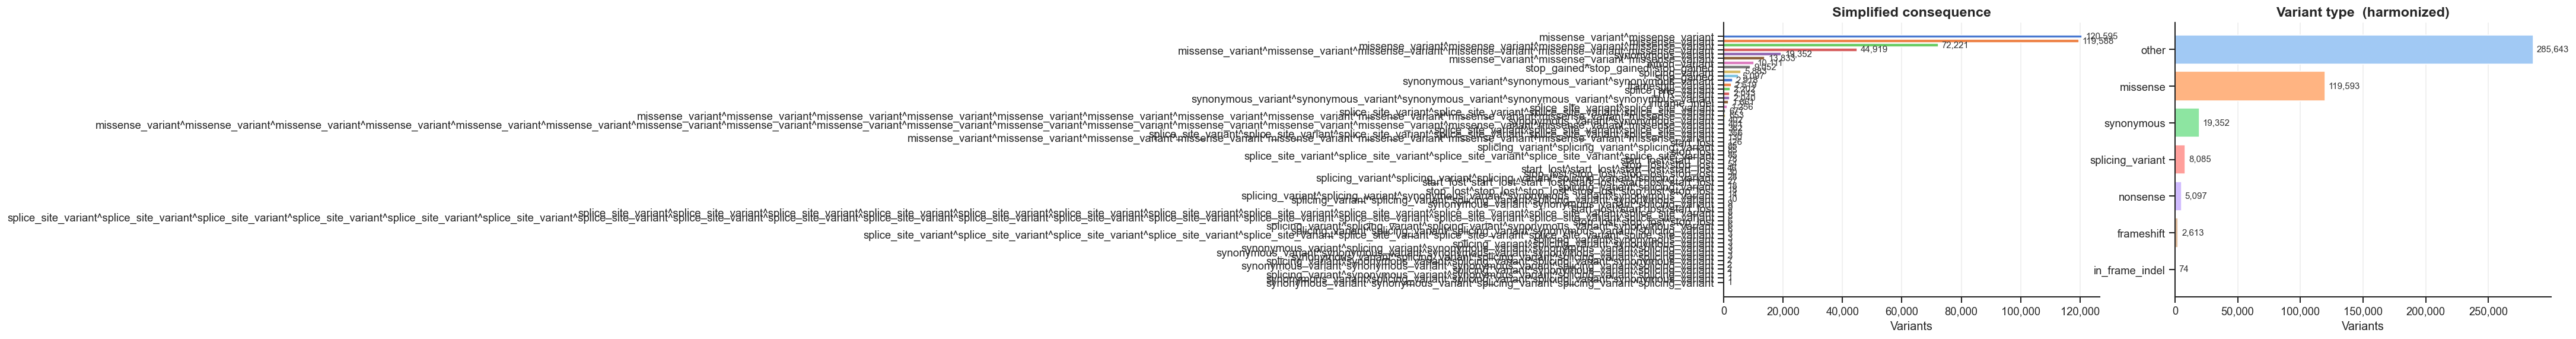

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Consequence
consq = df['simplified_consequence'].value_counts()
colors_c = sns.color_palette('muted', len(consq))
axes[0].barh(consq.index, consq.values, color=colors_c, edgecolor='white')
axes[0].set_title('Simplified consequence')
axes[0].set_xlabel('Variants')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(comma_fmt))
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.35)
for i, (val, lbl) in enumerate(zip(consq.values, consq.index)):
    axes[0].text(val + consq.values.max() * 0.01, i, f'{val:,}',
                 va='center', fontsize=9, color='#333')

# Variant type
vtype = df['variant_type_harmonized'].value_counts().dropna()
colors_v = sns.color_palette('pastel', len(vtype))
axes[1].barh(vtype.index, vtype.values, color=colors_v, edgecolor='white')
axes[1].set_title('Variant type  (harmonized)')
axes[1].set_xlabel('Variants')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(comma_fmt))
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.35)
for i, val in enumerate(vtype.values):
    axes[1].text(val + vtype.values.max() * 0.01, i, f'{val:,}',
                 va='center', fontsize=9, color='#333')

plt.show()

In [43]:
src = df['_source'].value_counts()
print('Variants by source dataset:')
print(src.to_string())

Variants by source dataset:
_source
pillar      440064
fisseq         338
labelseq       219
vampseq          5


---
## 3. Consensus Labels & Flags

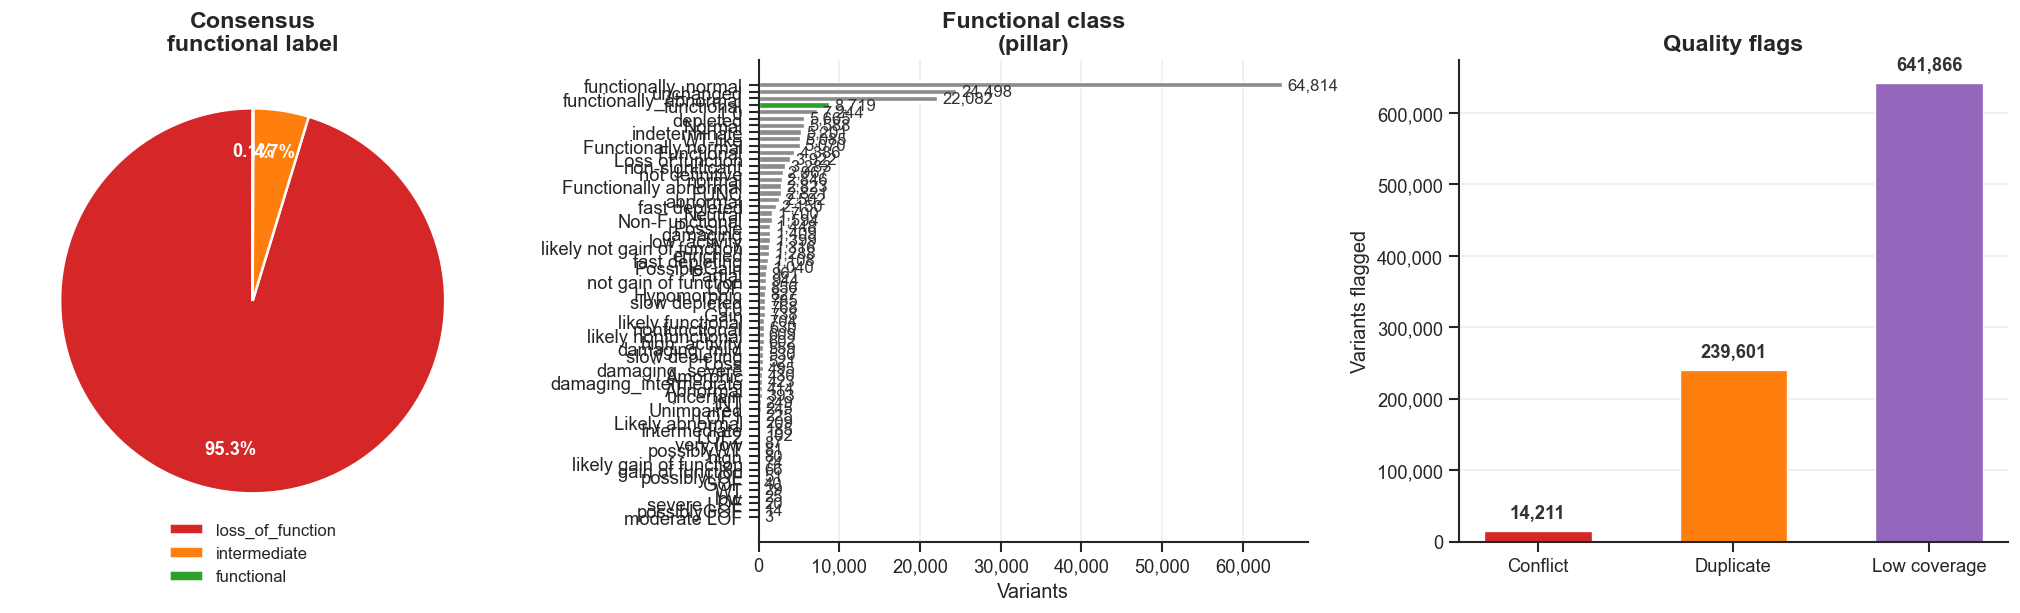

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Consensus label pie ───────────────────────────────────────────────────
lbl = df['consensus_functional_label'].value_counts()
pie_colors = [LABEL_PALETTE.get(k, '#aaa') for k in lbl.index]
wedges, texts, autotexts = axes[0].pie(
    lbl.values, labels=None, autopct='%1.1f%%', startangle=90,
    colors=pie_colors, pctdistance=0.78,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')
axes[0].legend(lbl.index, loc='lower center', bbox_to_anchor=(0.5, -0.12),
               ncol=1, frameon=False, fontsize=10)
axes[0].set_title('Consensus\nfunctional label')

# ── Pillar class bar ─────────────────────────────────────────────────────
pc = df['functional_class_pillar'].value_counts()
pc_colors = [LABEL_PALETTE.get(k, '#8c8c8c') for k in pc.index]
axes[1].barh(pc.index, pc.values, color=pc_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Functional class\n(pillar)')
axes[1].set_xlabel('Variants')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(comma_fmt))
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.35)
for i, val in enumerate(pc.values):
    axes[1].text(val + pc.values.max() * 0.01, i, f'{val:,}',
                 va='center', fontsize=10, color='#333')

# ── Quality flags ─────────────────────────────────────────────────────────
flag_cols = ['conflict_flag', 'is_duplicate_flag', 'low_coverage_flag']
flag_labels = ['Conflict', 'Duplicate', 'Low coverage']
flag_counts = df[flag_cols].sum()
flag_colors = ['#d62728', '#ff7f0e', '#9467bd']
bars = axes[2].bar(flag_labels, flag_counts.values, color=flag_colors,
                   edgecolor='white', linewidth=0.8, width=0.55)
axes[2].set_title('Quality flags')
axes[2].set_ylabel('Variants flagged')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(comma_fmt))
axes[2].grid(axis='y', alpha=0.35)
for bar, val in zip(bars, flag_counts.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, val + flag_counts.values.max() * 0.02,
                 f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333')

plt.show()

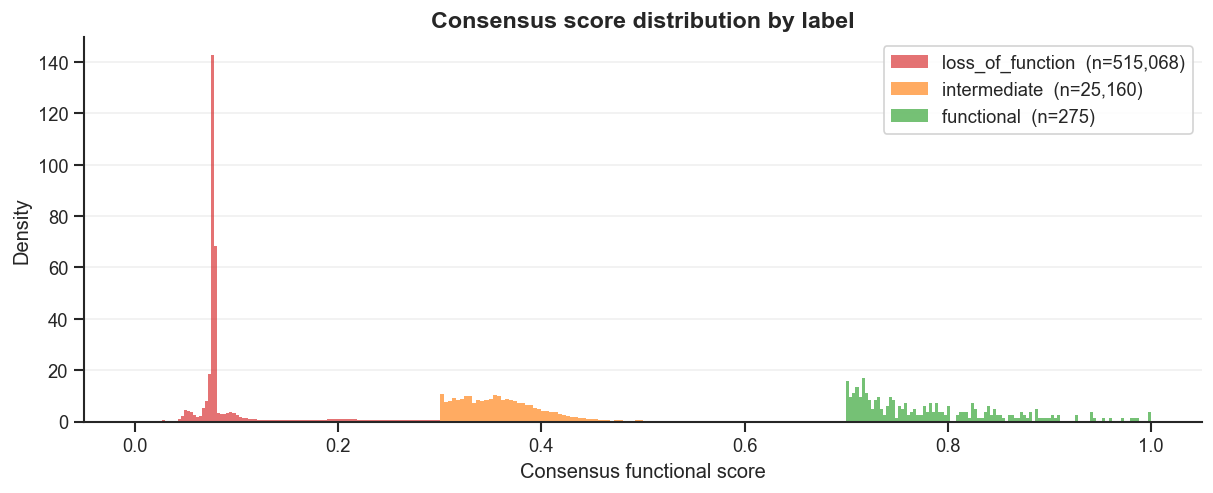

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))
sub = df.dropna(subset=['consensus_functional_score', 'consensus_functional_label'])
order = ['loss_of_function', 'intermediate', 'functional']
for lbl in order:
    if lbl not in sub['consensus_functional_label'].values:
        continue
    vals = sub.loc[sub['consensus_functional_label'] == lbl, 'consensus_functional_score']
    ax.hist(vals, bins=100, alpha=0.65, label=f'{lbl}  (n={len(vals):,})',
            color=LABEL_PALETTE[lbl], density=True, linewidth=0)

ax.set_xlabel('Consensus functional score')
ax.set_ylabel('Density')
ax.set_title('Consensus score distribution by label')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.show()

---
## 4. Computational Score Distributions

ModuleNotFoundError: No module named 'scipy'

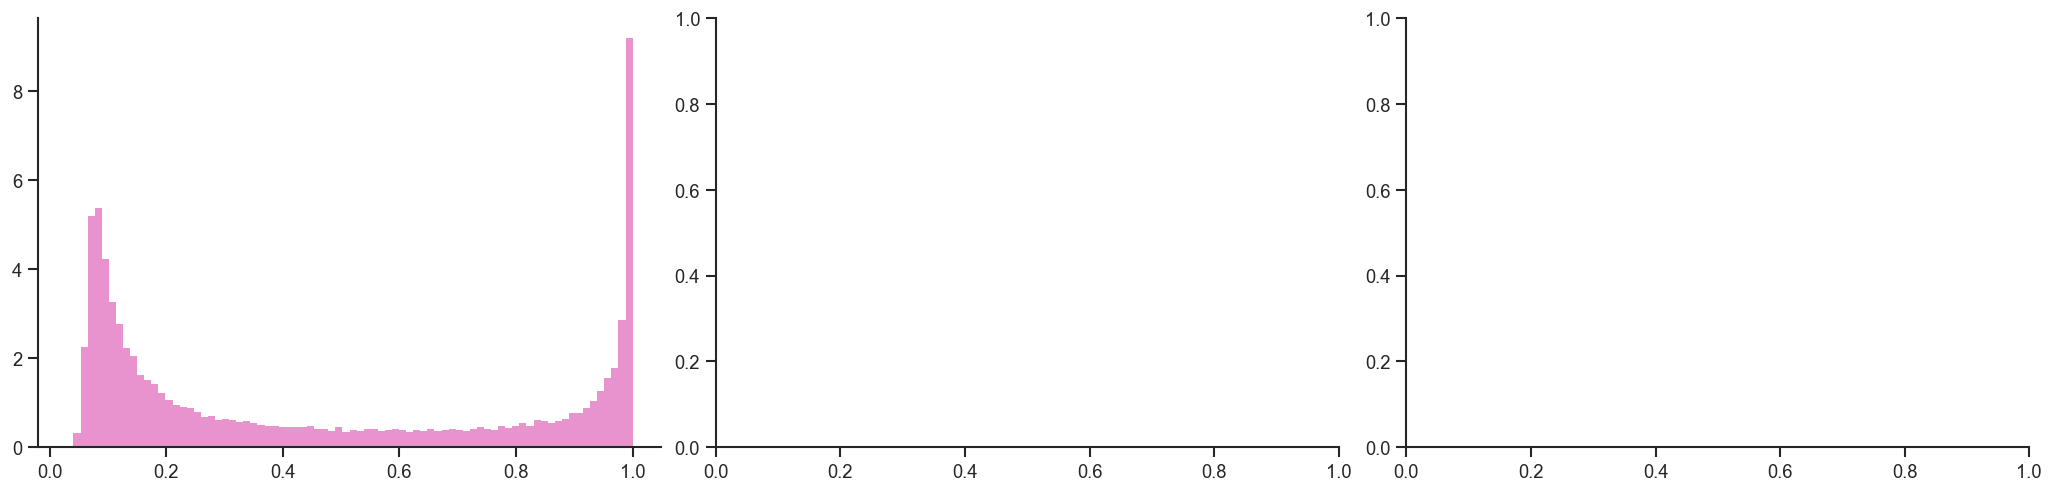

In [46]:
comp_scores = {
    'AlphaMissense': ('alphamissense_score', '#e377c2'),
    'REVEL':         ('revel_score',          '#17becf'),
    'SpliceAI max DS': ('spliceai_max_ds',    '#bcbd22'),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (name, (col, color)) in zip(axes, comp_scores.items()):
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    ax.hist(data, bins=80, color=color, alpha=0.8, density=True, linewidth=0)
    # KDE overlay
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data, bw_method='scott')
    xs = np.linspace(data.min(), data.max(), 300)
    ax.plot(xs, kde(xs), color='black', linewidth=1.5, label='KDE')
    ax.set_title(f'{name}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.text(0.97, 0.97, f'n = {len(data):,}\nμ = {data.mean():.3f}\nσ = {data.std():.3f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
    ax.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sub = df.dropna(subset=['alphamissense_score', 'consensus_functional_label']).copy()
sub['alphamissense_score'] = pd.to_numeric(sub['alphamissense_score'], errors='coerce')
sub = sub.dropna(subset=['alphamissense_score'])
order = [o for o in ['loss_of_function', 'intermediate', 'functional']
         if o in sub['consensus_functional_label'].unique()]
pal = [LABEL_PALETTE[o] for o in order]

# Box plot
sns.boxplot(data=sub, x='consensus_functional_label', y='alphamissense_score',
            order=order, palette=pal, width=0.5, linewidth=1.4,
            flierprops=dict(marker='.', markersize=2, alpha=0.3), ax=axes[0])
axes[0].set_title('AlphaMissense score by consensus label')
axes[0].set_xlabel('')
axes[0].set_ylabel('AlphaMissense score')
axes[0].grid(axis='y', alpha=0.3)

# Overlapping KDEs per label
from scipy.stats import gaussian_kde
for lbl in order:
    vals = sub.loc[sub['consensus_functional_label'] == lbl, 'alphamissense_score'].dropna()
    if len(vals) < 10:
        continue
    kde = gaussian_kde(vals, bw_method='scott')
    xs = np.linspace(0, 1, 400)
    axes[1].fill_between(xs, kde(xs), alpha=0.35, color=LABEL_PALETTE[lbl], label=lbl)
    axes[1].plot(xs, kde(xs), color=LABEL_PALETTE[lbl], linewidth=2)
axes[1].axvline(0.564, color='black', linewidth=1.2, linestyle='--', label='Pathogenic threshold (0.564)')
axes[1].set_xlabel('AlphaMissense score')
axes[1].set_ylabel('Density')
axes[1].set_title('AlphaMissense KDE by consensus label')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.show()
print('\nAlphaMissense label distribution:')
print(df['alphamissense_label'].value_counts().to_string())

---
## 5. Assay Score Coverage & Distributions

In [ ]:
top_genes = df['gene'].value_counts().head(20).index.tolist()

coverage = []
for gene in top_genes:
    gdf = df[df['gene'] == gene]
    row = {}
    for col, lbl in zip(SCORE_COLS, SCORE_LABELS):
        num = pd.to_numeric(gdf[col], errors='coerce')
        row[lbl] = num.notna().mean() * 100
    coverage.append(row)

cov_df = pd.DataFrame(coverage, index=top_genes)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    cov_df, annot=True, fmt='.0f', cmap='YlGnBu',
    linewidths=0.6, linecolor='white',
    cbar_kws={'label': '% coverage', 'shrink': 0.7},
    annot_kws={'size': 10}, ax=ax
)
ax.set_title('Score coverage (%) per gene — top 20 genes', pad=12)
ax.set_xlabel('Score')
ax.set_ylabel('Gene')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.show()

In [ ]:
assay_scores = {
    'Pillar':   ('functional_score_pillar',   '#4878cf'),
    'VampSeq':  ('functional_score_vampseq',  '#6acc65'),
    'LabelSeq': ('functional_score_labelseq', '#d65f5f'),
    'FISSeq':   ('functional_score_fisseq',   '#b47cc7'),
}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
order = ['loss_of_function', 'intermediate', 'functional']

for ax, (name, (col, base_color)) in zip(axes.flat, assay_scores.items()):
    sub = df.dropna(subset=[col, 'consensus_functional_label'])
    from scipy.stats import gaussian_kde
    for lbl in order:
        if lbl not in sub['consensus_functional_label'].values:
            continue
        vals = sub.loc[sub['consensus_functional_label'] == lbl, col].dropna()
        if len(vals) < 5:
            continue
        ax.hist(vals, bins=70, alpha=0.45, color=LABEL_PALETTE[lbl],
                density=True, linewidth=0)
        kde = gaussian_kde(vals, bw_method='scott')
        xs = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(xs, kde(xs), color=LABEL_PALETTE[lbl], linewidth=2,
                label=f'{lbl}  (n={len(vals):,})')
    ax.set_title(f'{name} functional score')
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.show()

---
## 6. Score Correlations

In [ ]:
corr_df = df[SCORE_COLS].copy()
for col in SCORE_COLS:
    corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')
corr_df.columns = SCORE_LABELS

corr_matrix = corr_df.corr(method='spearman')
overlap = corr_df.notna().T.dot(corr_df.notna())  # pairwise n

# Combined annotation: corr (n=…)
annot = corr_matrix.copy().astype(str)
for r in corr_matrix.index:
    for c in corr_matrix.columns:
        n = int(overlap.loc[r, c])
        annot.loc[r, c] = f'{corr_matrix.loc[r,c]:.2f}\n(n={n:,})'

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, mask=mask, annot=annot, fmt='', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, linecolor='white',
    vmin=-1, vmax=1, cbar_kws={'label': 'Spearman ρ', 'shrink': 0.7},
    annot_kws={'size': 8.5}, ax=ax
)
ax.set_title('Spearman correlation between scores\n(lower triangle; n = pairwise non-null)', pad=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.show()

In [ ]:
# Scatter: Pillar vs AlphaMissense
sub = df[['functional_score_pillar', 'alphamissense_score', 'consensus_functional_label']].copy()
sub['alphamissense_score'] = pd.to_numeric(sub['alphamissense_score'], errors='coerce')
sub = sub.dropna().sample(min(6000, len(sub)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
order = ['loss_of_function', 'intermediate', 'functional']
for lbl in order:
    if lbl not in sub['consensus_functional_label'].values:
        continue
    g = sub[sub['consensus_functional_label'] == lbl]
    ax.scatter(g['functional_score_pillar'], g['alphamissense_score'],
               alpha=0.35, s=10, label=lbl, color=LABEL_PALETTE[lbl], linewidths=0)

ax.set_xlabel('Pillar functional score')
ax.set_ylabel('AlphaMissense score')
ax.set_title('Pillar vs AlphaMissense  (random sample, n = 6,000)')
ax.legend(markerscale=3, title='Consensus label')
ax.grid(alpha=0.25)
plt.show()

---
## 7. ClinVar Overview

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

CV_PALETTE = {
    'Pathogenic':                   '#d62728',
    'Likely pathogenic':            '#ff7f0e',
    'Uncertain significance':       '#aec7e8',
    'Likely benign':                '#98df8a',
    'Benign':                       '#2ca02c',
    'Pathogenic/Likely pathogenic': '#e05c5c',
    'Benign/Likely benign':         '#4caf87',
}

for ax, col, title in [
    (axes[0], 'pillar__clinvar_sig_2025', 'ClinVar significance — 2025'),
    (axes[1], 'pillar__clinvar_sig_2018', 'ClinVar significance — 2018'),
]:
    vc = df[col].value_counts().head(12)
    colors = [CV_PALETTE.get(k, '#cccccc') for k in vc.index]
    ax.barh(range(len(vc)), vc.values, color=colors, edgecolor='white', linewidth=0.6)
    ax.set_yticks(range(len(vc)))
    ax.set_yticklabels(vc.index, fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('Variants')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(comma_fmt))
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.35)
    for i, val in enumerate(vc.values):
        ax.text(val + vc.values.max() * 0.01, i, f'{val:,}',
                va='center', fontsize=9, color='#333')

plt.show()
print('ClinVar star rating (2025):')
print(df['pillar__clinvar_star_2025'].value_counts().to_string())

---
## 8. Per-Assay Deep Dives

In [ ]:
# ── VampSeq ───────────────────────────────────────────────────────────────
from scipy.stats import gaussian_kde
vs = df.dropna(subset=['functional_score_vampseq']).copy()
print(f'VampSeq rows: {len(vs):,}')
print('Gene coverage:')
print(vs['gene'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

vals = vs['functional_score_vampseq']
axes[0].hist(vals, bins=70, color='#6acc65', alpha=0.75, density=True, linewidth=0)
kde = gaussian_kde(vals.dropna(), bw_method='scott')
xs = np.linspace(vals.min(), vals.max(), 300)
axes[0].plot(xs, kde(xs), color='black', linewidth=1.8)
axes[0].set_title('VampSeq functional score')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Density')
axes[0].text(0.97, 0.97, f'n = {len(vals):,}\nμ = {vals.mean():.3f}',
             transform=axes[0].transAxes, va='top', ha='right', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
axes[0].grid(axis='y', alpha=0.3)

gene_order = vs['gene'].value_counts().index.tolist()
sns.boxplot(data=vs, x='gene', y='functional_score_vampseq', order=gene_order,
            palette='Set3', width=0.5, linewidth=1.2,
            flierprops=dict(marker='.', markersize=2, alpha=0.3), ax=axes[1])
axes[1].set_title('VampSeq score by gene')
axes[1].set_xlabel('')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# ── LabelSeq ──────────────────────────────────────────────────────────────
ls = df.dropna(subset=['functional_score_labelseq']).copy()
print(f'LabelSeq rows: {len(ls):,}')
print('Gene coverage:')
print(ls['gene'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

vals = ls['functional_score_labelseq']
axes[0].hist(vals, bins=70, color='#d65f5f', alpha=0.75, density=True, linewidth=0)
kde = gaussian_kde(vals.dropna(), bw_method='scott')
xs = np.linspace(vals.min(), vals.max(), 300)
axes[0].plot(xs, kde(xs), color='black', linewidth=1.8)
axes[0].set_title('LabelSeq functional score')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Density')
axes[0].text(0.97, 0.97, f'n = {len(vals):,}\nμ = {vals.mean():.3f}',
             transform=axes[0].transAxes, va='top', ha='right', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
axes[0].grid(axis='y', alpha=0.3)

top_ls = ls['gene'].value_counts().head(10).index.tolist()
sns.boxplot(data=ls[ls['gene'].isin(top_ls)], x='gene', y='functional_score_labelseq',
            order=top_ls, palette='Set2', width=0.5, linewidth=1.2,
            flierprops=dict(marker='.', markersize=2, alpha=0.3), ax=axes[1])
axes[1].set_title('LabelSeq score by gene  (top 10)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# ── FISSeq ────────────────────────────────────────────────────────────────
fs = df.dropna(subset=['functional_score_fisseq']).copy()
print(f'FISSeq rows: {len(fs):,}')
print('Gene coverage:')
print(fs['gene'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

vals = fs['functional_score_fisseq']
axes[0].hist(vals, bins=50, color='#b47cc7', alpha=0.75, density=True, linewidth=0)
kde = gaussian_kde(vals.dropna(), bw_method='scott')
xs = np.linspace(vals.min(), vals.max(), 300)
axes[0].plot(xs, kde(xs), color='black', linewidth=1.8)
axes[0].set_title('FISSeq functional score')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Density')
axes[0].text(0.97, 0.97, f'n = {len(vals):,}\nμ = {vals.mean():.3f}',
             transform=axes[0].transAxes, va='top', ha='right', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
axes[0].grid(axis='y', alpha=0.3)

sns.boxplot(data=fs, x='gene', y='functional_score_fisseq',
            palette='Pastel1', width=0.5, linewidth=1.2,
            flierprops=dict(marker='.', markersize=2, alpha=0.3), ax=axes[1])
axes[1].set_title('FISSeq score by gene')
axes[1].set_xlabel('')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
plt.show()

print('\nFISSeq cluster distribution:')
print(fs['fisseq_cluster'].value_counts().to_string())

---
## 9. FISSeq UMAP Visualisation

In [ ]:
umap_df = df.dropna(subset=['fisseq_umap1', 'fisseq_umap2', 'fisseq_cluster']).copy()
print(f'FISSeq UMAP points: {len(umap_df):,}')

clusters = sorted(umap_df['fisseq_cluster'].unique())
cluster_pal = dict(zip(clusters, sns.color_palette('tab10', len(clusters))))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Cluster view
for clust in clusters:
    mask = umap_df['fisseq_cluster'] == clust
    axes[0].scatter(umap_df.loc[mask, 'fisseq_umap1'], umap_df.loc[mask, 'fisseq_umap2'],
                    c=[cluster_pal[clust]], s=8, alpha=0.7, linewidths=0,
                    label=f'Cluster {int(clust)}')
axes[0].set_title('FISSeq UMAP — coloured by cluster')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(markerscale=2.5, title='Cluster', fontsize=9,
               loc='best', framealpha=0.85)

# AUROC view
auroc_df = umap_df.dropna(subset=['fisseq_auroc'])
sc = axes[1].scatter(auroc_df['fisseq_umap1'], auroc_df['fisseq_umap2'],
                     c=auroc_df['fisseq_auroc'], cmap='RdYlGn',
                     s=8, alpha=0.8, linewidths=0, vmin=0, vmax=1)
cb = plt.colorbar(sc, ax=axes[1], label='AUROC', shrink=0.85)
cb.ax.tick_params(labelsize=10)
axes[1].set_title('FISSeq UMAP — coloured by AUROC')
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

plt.show()

---
## 10. Amino-Acid Position Score Tracks

In [ ]:
def plot_position_track(gene, score_col, score_label, color, threshold=None, threshold_label=None):
    gdf = df[(df['gene'] == gene)].copy()
    gdf['aa_pos'] = pd.to_numeric(gdf['aa_pos'], errors='coerce')
    gdf[score_col] = pd.to_numeric(gdf[score_col], errors='coerce')
    gdf = gdf.dropna(subset=['aa_pos', score_col])

    pos_score = gdf.groupby('aa_pos')[score_col].mean()
    pos_n     = gdf.groupby('aa_pos')[score_col].count()

    fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True,
                              gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.08})

    axes[0].bar(pos_score.index, pos_score.values, width=1.0,
                color=color, alpha=0.8, linewidth=0)
    if threshold is not None:
        axes[0].axhline(threshold, color='black', linewidth=1.2, linestyle='--',
                        label=threshold_label or f'threshold = {threshold}')
        axes[0].legend()
    axes[0].set_ylabel(f'Mean {score_label} score')
    axes[0].set_title(f'{gene} — mean {score_label} score per AA position  (n = {len(gdf):,} variants)')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(pos_n.index, pos_n.values, width=1.0, color='#aaaaaa', linewidth=0)
    axes[1].set_ylabel('Count')
    axes[1].set_xlabel('Amino-acid position')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(comma_fmt))
    axes[1].grid(axis='y', alpha=0.3)

    plt.show()

plot_position_track('TP53', 'functional_score_pillar', 'Pillar', '#4878cf')
plot_position_track('BRCA1', 'alphamissense_score', 'AlphaMissense', '#e377c2',
                    threshold=0.564, threshold_label='Pathogenic threshold (0.564)')

---
## 11. Conflict & Duplicate Analysis

In [ ]:
conflict_df = df[df['conflict_flag'] == True]
dup_df      = df[df['is_duplicate_flag'] == True]
print(f'Conflict variants: {len(conflict_df):,}')
print(f'Duplicate variants: {len(dup_df):,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fdf, title, color in [
    (axes[0], conflict_df,  'Genes with most conflicts',  '#d62728'),
    (axes[1], dup_df,       'Genes with most duplicates', '#ff7f0e'),
]:
    vc = fdf['gene'].value_counts().head(15)
    ax.barh(vc.index, vc.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Variants')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(comma_fmt))
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.35)
    for i, val in enumerate(vc.values):
        ax.text(val + vc.values.max() * 0.01, i, f'{val:,}',
                va='center', fontsize=9, color='#333')

plt.show()

In [ ]:
if len(conflict_df) > 0:
    sub_c = conflict_df.dropna(subset=['functional_score_pillar', 'gene'])
    gene_order = sub_c['gene'].value_counts().head(15).index.tolist()
    sub_c = sub_c[sub_c['gene'].isin(gene_order)]

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=sub_c, x='gene', y='functional_score_pillar', order=gene_order,
                color='#d62728', width=0.5, linewidth=1.2,
                flierprops=dict(marker='.', markersize=2, alpha=0.3), ax=ax)
    ax.set_title('Pillar score spread for conflicted variants  (top 15 genes)')
    ax.set_xlabel('')
    ax.set_ylabel('Pillar functional score')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.3)
    plt.show()

---
## 12. Ad-hoc Query Playground

In [ ]:
# Filter to a specific gene + consequence and inspect
query_gene  = 'BRCA1'
query_consq = 'missense_variant'

result = df[
    (df['gene'] == query_gene) &
    (df['simplified_consequence'] == query_consq)
][['variant_id','hgvs_p','aa_pos','aa_ref','aa_alt',
   'functional_score_pillar','alphamissense_score','consensus_functional_label']]

print(f'{query_gene} — {query_consq}: {len(result):,} rows')
result.head(20)

In [ ]:
# Variants scored by ALL 4 assays
all_scored = df.dropna(subset=['functional_score_pillar','functional_score_vampseq',
                                'functional_score_labelseq','functional_score_fisseq'])
print(f'Variants with all 4 assay scores: {len(all_scored):,}')
print(all_scored['gene'].value_counts().to_string())

In [ ]:
# Descriptive stats for numeric score columns
num_cols = SCORE_COLS + ['consensus_functional_score']
num_df = df[num_cols].copy()
for c in num_df.columns:
    num_df[c] = pd.to_numeric(num_df[c], errors='coerce')
num_df.columns = SCORE_LABELS + ['Consensus']
num_df.describe().round(4)